In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("powerplant_data.csv")

In [ ]:
df.head()


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [ ]:
df.shape

(9568, 5)

In [ ]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [ ]:
x=df.drop(columns=["PE"])

In [ ]:
y=df["PE"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


In [ ]:
import torch
import torch.nn as nn

x_train_tensor=torch.tensor(x_train,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

x_test_tensor=torch.tensor(x_test,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)


In [ ]:
#tensordataset&dataloader

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

training_data=TensorDataset(x_train_tensor,y_train_tensor)
test_data=TensorDataset(x_test_tensor,y_test_tensor)

In [ ]:
train_loader=DataLoader(training_data,batch_size=32, shuffle=True)
test_loader=DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
#buliding ann model

In [ ]:
class Ann(nn.Module):
  def __init__(self):
    super(Ann, self).__init__()

    self.model=nn.Sequential(
      nn.Linear(x_train.shape[1], 6),
      nn.ReLU(),

      nn.Linear(6,6),
      nn.ReLU(),

      nn.Linear(6,1)
  )

  def forward(self, x):
    return self.model(x)



In [ ]:
model=Ann()
# loss, optimizer
import torch.optim as optim
cirterion=nn.MSELoss()

optimizer=optim.Adam(model.parameters())

In [ ]:
#training the Ann
train_losses=[]
valid_losses=[]
best_val_loss=float("inf")

epochs=100
for ep in range(epochs):

    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = cirterion(outputs, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    running_val_loss = 0.0
    model.eval()

    with torch.no_grad():

        for xb, yb in test_loader:
            outputs = model(xb)
            loss = cirterion(outputs, yb)

            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)


    print(f"epoch {ep+1}/{epochs}==> train_loss={epoch_train_loss} &val_loss={epoch_val_loss}")
    if epoch_val_loss<best_val_loss:
      best_val_loss=epoch_val_loss
      torch.save(model.state_dict(), "best_model.pt")


epoch 1/100==> train_loss=205717.56614583332 &val_loss=203064.0
epoch 2/100==> train_loss=192083.86334635416 &val_loss=173969.953125
epoch 3/100==> train_loss=144519.9555013021 &val_loss=111419.8671875
epoch 4/100==> train_loss=80989.02679036459 &val_loss=54918.95703125
epoch 5/100==> train_loss=40342.216528320314 &val_loss=29085.5625
epoch 6/100==> train_loss=23746.61641031901 &val_loss=19009.556640625
epoch 7/100==> train_loss=16702.611482747398 &val_loss=14134.150390625
epoch 8/100==> train_loss=12635.89512532552 &val_loss=10555.853515625
epoch 9/100==> train_loss=9230.530373128255 &val_loss=7460.34130859375
epoch 10/100==> train_loss=6384.059487915039 &val_loss=4992.203125
epoch 11/100==> train_loss=4265.039221191406 &val_loss=3292.553955078125
epoch 12/100==> train_loss=2854.2224210103354 &val_loss=2208.553466796875
epoch 13/100==> train_loss=1955.8151242574056 &val_loss=1517.845703125
epoch 14/100==> train_loss=1363.5416211446127 &val_loss=1052.8846435546875
epoch 15/100==> train

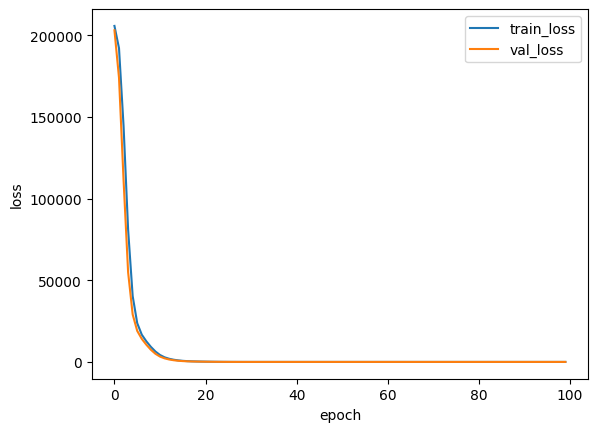

In [ ]:
import matplotlib.pyplot as plt
loss=pd.DataFrame({"train_loss":train_losses,"val_loss":valid_losses})
plt.plot(loss["train_loss"], label="train_loss")
plt.plot(loss["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.show()

In [ ]:
print(len(train_losses))
print(len(valid_losses))

100
100


In [ ]:
print(y_train.min())
print(y_train.max())
print(y_test.min())
print(y_test.max())

420.26
495.76
425.16
494.87


In [ ]:
print(y_train.min())
print(y_train.max())
print(y_test.min())
print(y_test.max())

420.26
495.76
425.16
494.87


In [ ]:
print(train_losses[:5])
print(valid_losses[:5])
print(train_losses[-5:])
print(valid_losses[-5:])

[205717.56614583332, 192083.86334635416, 144519.9555013021, 80989.02679036459, 40342.216528320314]
[tensor(203064.), tensor(173969.9531), tensor(111419.8672), tensor(54918.9570), tensor(29085.5625)]
[20.646843258539835, 20.8084277788798, 20.815148544311523, 20.713620181878408, 20.723214968045554]
[tensor(21.3481), tensor(18.8758), tensor(18.9629), tensor(19.4927), tensor(18.7936)]


In [ ]:
# loading the best model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [ ]:
#Evalution of the model
model.eval()
with torch.no_grad():
 train_preds=model(x_train_tensor)
 test_preds=model(x_test_tensor)

 train_mse_loss=cirterion(train_preds, y_train_tensor)
 test_mse_loss=cirterion(test_preds, y_test_tensor)

 print(f"train_mse_loss={train_mse_loss}")
 print(f"test_mse_loss={test_mse_loss}")

train_mse_loss=20.36404037475586
test_mse_loss=18.733089447021484


In [ ]:
from sklearn.metrics import r2_score
train_r2=r2_score(y_train, train_preds)
test_r2=r2_score(y_test, test_preds)
test_r2

0.9345326892446719

In [ ]:
predicted_df=pd.DataFrame(test_preds.numpy(), columns=["Predicted"])
actual_df=pd.DataFrame(y_test.values, columns=["Actual"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted,Actual
0,435.093506,433.27
1,436.998718,438.16
2,461.506989,458.42
3,476.695953,480.82
4,435.200623,441.41
...,...,...
1909,451.493866,456.70
1910,431.559448,438.04
1911,467.711090,467.80
1912,431.015289,437.14
